<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>AdaBoost From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
AdaBoost (Adaptive Boosting) is the classic boosting algorithm. The whole thing is just reweighting the training points each round and then doing a weighted vote at the end. I'll build it with plain functions and check it against sklearn.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_gaussian_quantiles
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## The algorithm in words

AdaBoost wants the labels as -1 and +1 (it makes the math cleaner). Then:

1. start with every point having the same weight, 1/N
2. train a weak stump using those weights
3. work out its weighted error (how much weight is on the points it got wrong)
4. give the stump a say `alpha = 0.5 * ln((1 - err) / err)`, so accurate stumps get a bigger say
5. multiply the weight of every point by `exp(-alpha * y * pred)`, which pushes weight onto the misclassified ones, then normalise
6. repeat, and predict with the weighted vote `sign(sum of alpha * stump prediction)`

In [2]:
X, y = make_gaussian_quantiles(n_samples=500, n_features=2, n_classes=2, random_state=42)
y = np.where(y == 0, -1, 1)   # adaboost likes -1 / +1

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)
print(Xtr.shape, Xte.shape)

(350, 2) (150, 2)


## One weighted stump

The weak learner is just a depth 1 tree, and sklearn lets us pass sample weights into fit, so i dont have to rewrite the tree itself, only the boosting around it.

In [3]:
def fit_stump(X, y, weights):
    stump = DecisionTreeClassifier(max_depth=1)
    stump.fit(X, y, sample_weight=weights)
    return stump

## The boosting loop

This is the actual AdaBoost. It returns a list of (stump, alpha) pairs.

In [4]:
def adaboost_fit(X, y, n_rounds):
    n = len(y)
    w = np.ones(n) / n          # start all weights equal
    models = []

    for m in range(n_rounds):
        stump = fit_stump(X, y, w)
        pred = stump.predict(X)

        # weighted error, clipped so we never divide by zero
        err = np.clip(np.sum(w * (pred != y)) / np.sum(w), 1e-10, 1 - 1e-10)
        alpha = 0.5 * np.log((1 - err) / err)

        # bump up the weight on the points we got wrong
        w = w * np.exp(-alpha * y * pred)
        w = w / w.sum()

        models.append((stump, alpha))
    return models

In [5]:
models = adaboost_fit(Xtr, ytr, n_rounds=50)

# peek at the say each of the first few stumps got
print([round(a, 3) for _, a in models[:5]])

[np.float64(0.281), np.float64(0.228), np.float64(0.312), np.float64(0.236), np.float64(0.361)]


## Predicting

Every stump votes, but its vote is scaled by its alpha, then we just take the sign.

In [6]:
def adaboost_predict(X, models):
    total = sum(alpha * stump.predict(X) for stump, alpha in models)
    return np.sign(total)

In [10]:
train_acc = accuracy_score(ytr, adaboost_predict(Xtr, models))
test_acc = accuracy_score(yte, adaboost_predict(Xte, models))
print('our adaboost  train:', round(train_acc, 3), ' test:', round(test_acc, 3))

sk = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                        n_estimators=50, algorithm='SAMME', random_state=42).fit(Xtr, ytr)
print('sklearn adaboost test:', round(accuracy_score(yte, sk.predict(Xte)), 3))

our adaboost  train: 0.969  test: 0.94
sklearn adaboost test: 0.94


/opt/anaconda3/lib/python3.13/site-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Watching it improve round by round</b>
</h2>
<div style="font-family:'Times New Roman';">
One nice thing about boosting is you can watch the test accuracy climb as you add more stumps. Early on its weak, then it shoots up and slowly levels off.
</div>

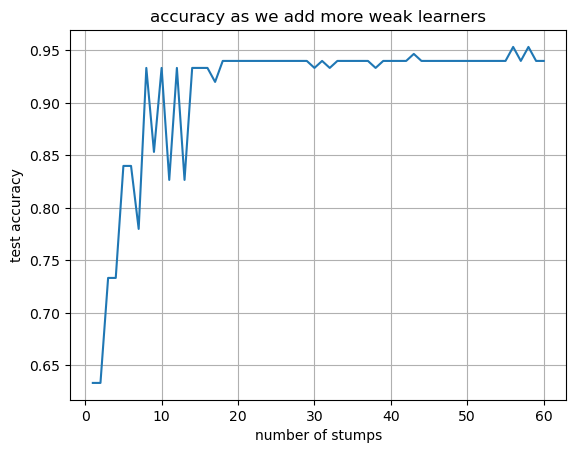

In [7]:
rounds = range(1, 61)
accs = []
for r in rounds:
    M = adaboost_fit(Xtr, ytr, r)
    accs.append(accuracy_score(yte, adaboost_predict(Xte, M)))

plt.plot(list(rounds), accs)
plt.xlabel('number of stumps')
plt.ylabel('test accuracy')
plt.title('accuracy as we add more weak learners')
plt.grid(True)
plt.show()